# Analyze Reconstruction Performance

This notebook loads the reconstruction analysis results generated by `evaluate_reconstruction.py`. It visualizes both the average R² score per channel and the reconstruction error over time.

### 1. Setup and Imports

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd

# Make sure your packages are installed in editable mode
from mhd_surrogate_core.plot import plot_reconstruction_performance, plot_reconstruction_error_over_time

### 2. Specify Evaluation File Path and Analyze

**Action Required:** Change the `eval_file_path` variable below to point to the specific `reconstruction_analysis.npz` file you want to analyze.

2025-07-06 20:38:11,076 - INFO - Loading reconstruction performance from /raid/skowronek/eval/param_sweep_04_07_25/lr_1e-4_ld_1024_wr_1.0_wp_1.0_wl_10.0_we_0.1/reconstruction_analysis_train_val.npz...


--- RECONSTRUCTION SUMMARY ---
Overall R² Score: -0.2400


--- Average Reconstruction Performance (R²) ---


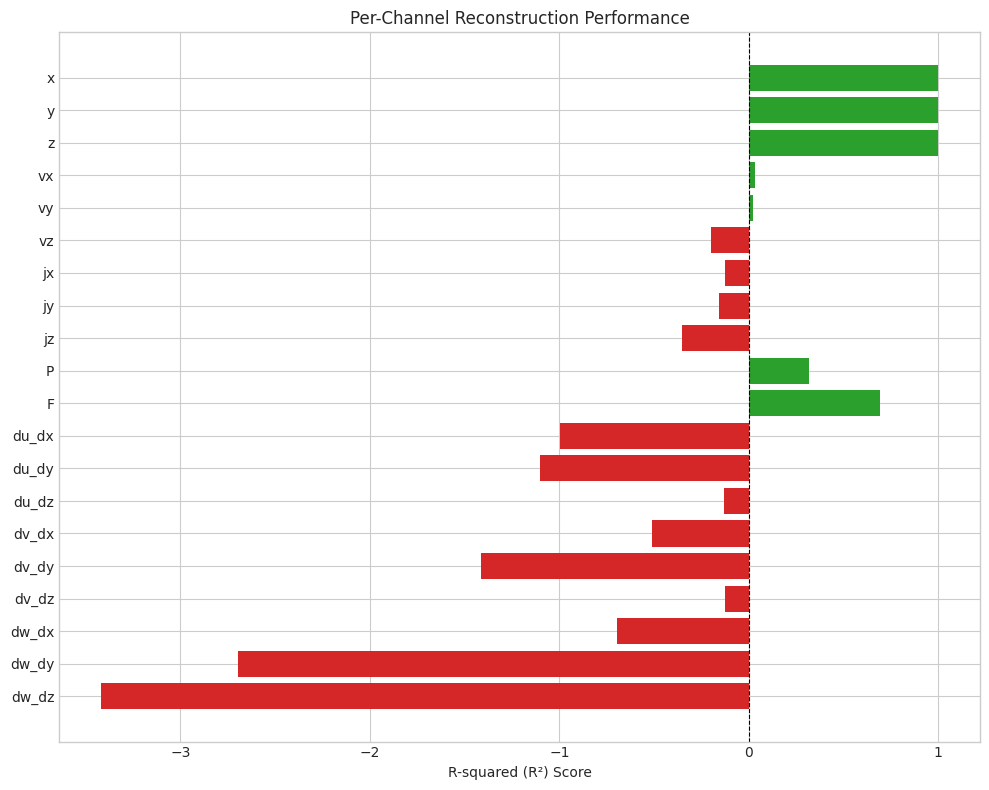

2025-07-06 20:38:11,341 - INFO - Loading reconstruction error from /raid/skowronek/eval/param_sweep_04_07_25/lr_1e-4_ld_1024_wr_1.0_wp_1.0_wl_10.0_we_0.1/reconstruction_analysis_train_val.npz...



--- Reconstruction Error Over Time ---


/cephfs/users/skowronek/Documents/PhD/nuclear_fusion_cooling/prediction/mhd_surrogate_modelling/packages/mhd_surrogate_core/src/mhd_surrogate_core/plot.py:260: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.96]); plt.show()


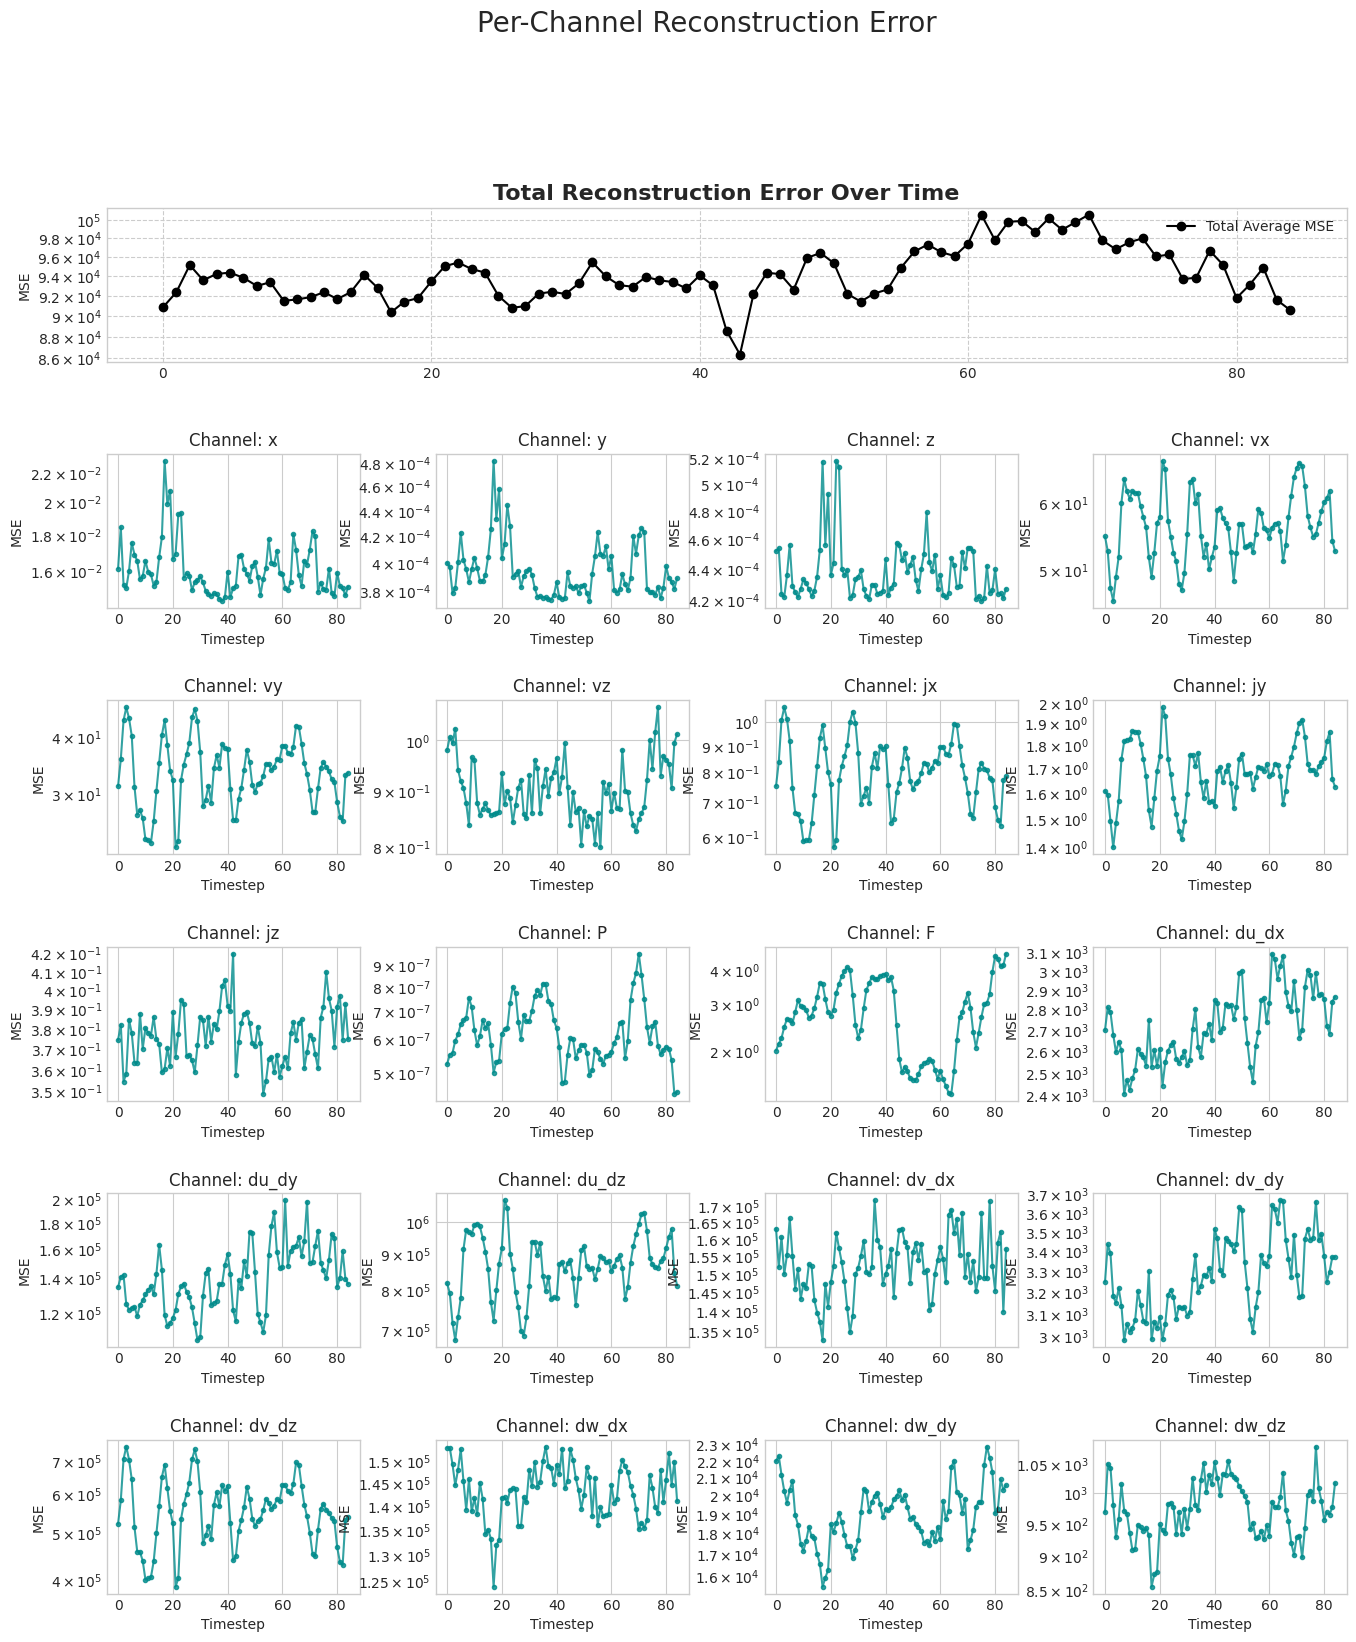

In [4]:
# Example path - update this to your specific run's output.
eval_file_path = Path("/raid/skowronek/eval/param_sweep_04_07_25/lr_1e-4_ld_1024_wr_1.0_wp_1.0_wl_10.0_we_0.1/reconstruction_analysis_train_val.npz")

if eval_file_path.exists():
    # --- Load Summary Metrics ---
    with np.load(eval_file_path, allow_pickle=True) as data:
        channel_names = data['channel_names']
        r_squared_total = data['r_squared_total']
        r_squared_per_channel = data['r_squared_per_channel']
    
    print(f"--- RECONSTRUCTION SUMMARY ---")
    print(f"Overall R² Score: {r_squared_total:.4f}\n")
    
    # --- Generate Plots ---
    print("\n--- Average Reconstruction Performance (R²) ---")
    plot_reconstruction_performance(eval_file_path)
    
    print("\n--- Reconstruction Error Over Time ---")
    plot_reconstruction_error_over_time(eval_file_path)
else:
    print(f"ERROR: Error file not found at {eval_file_path}")
    print("Please run evaluate_reconstruction.py first and/or update the path.")